# 1. RAF-DB + AffectNet Data Prep
Dataset preparation, targeted balancing, and visualization of balancing.

100%|██████████| 37.7M/37.7M [00:02<00:00, 13.3MB/s]

Extracting files...


kagglehub path: /root/.cache/kagglehub/datasets/shuvoalok/raf-db-dataset/versions/2


100%|██████████| 8.12G/8.12G [06:27<00:00, 22.5MB/s]

Extracting files...


kagglehub path: /root/.cache/kagglehub/datasets/manavukani/affectnet/versions/1
RAF root: /content/data/raf-db
AffectNet root: /content/data/affectnet
[RAF-DB] root=/content/data/raf-db
  total images: 15339
  label-from-path matches (sampled): 10000
[AffectNet] root=/content/data/affectnet
  total images: 31002
  label-from-path matches (sampled): 10000
RAF-DB images parsed: 15339
AffectNet images parsed: 27823
RAF-DB counts: {'surprise': 1619, 'fear': 355, 'disgust': 877, 'happiness': 5957, 'sadness': 2460, 'anger': 867, 'neutral': 3204}
AffectNet counts: {'surprise': 4296, 'fear': 3622, 'disgust': 2660, 'happiness': 5045, 'sadness': 3430, 'anger': 3638, 'neutral': 5132}
Merged counts: {'surprise': 5915, 'fear': 3977, 'disgust': 3537, 'happiness': 11002, 'sadness': 5890, 'anger': 4505, 'neutral': 8336}


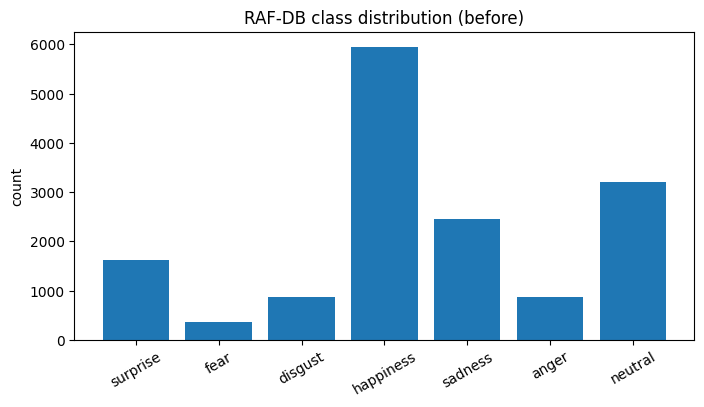

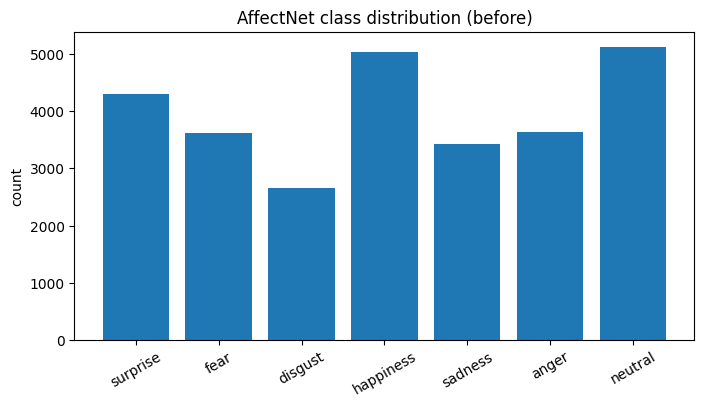

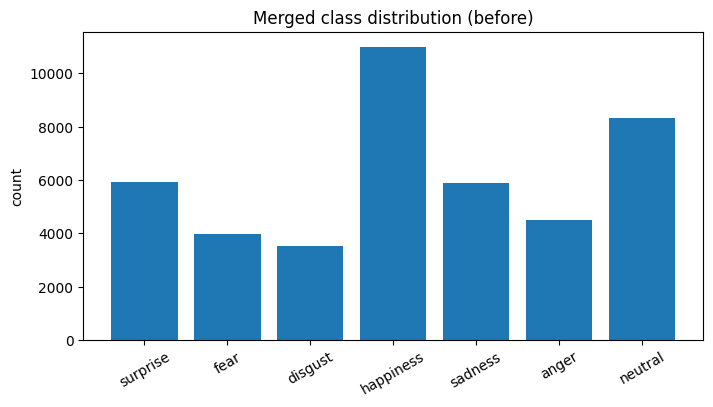

Target classes: ['surprise', 'fear', 'disgust', 'happiness', 'sadness', 'anger', 'neutral']
Calibration classes: []
Added from AffectNet: 4282
After dedup total: 19588
After full rebalance (downsample+topup): {'surprise': 2000, 'fear': 1984, 'disgust': 1990, 'happiness': 2000, 'sadness': 2000, 'anger': 1995, 'neutral': 2000}
Counts after: {'surprise': 2000, 'fear': 1984, 'disgust': 1990, 'happiness': 2000, 'sadness': 2000, 'anger': 1995, 'neutral': 2000}


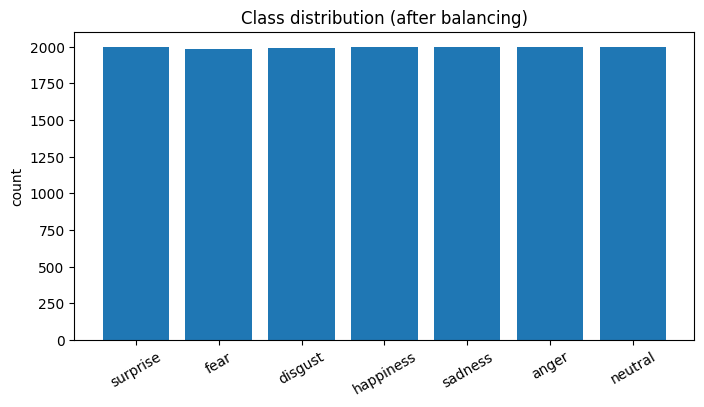

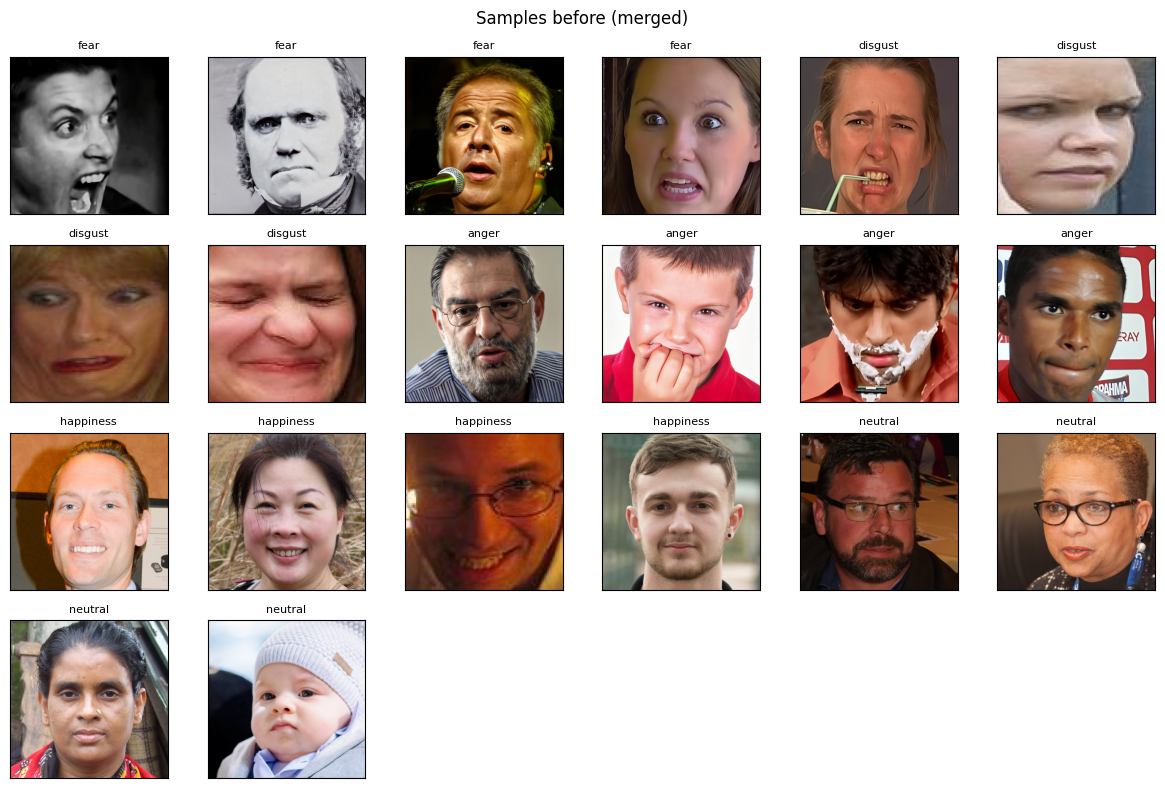

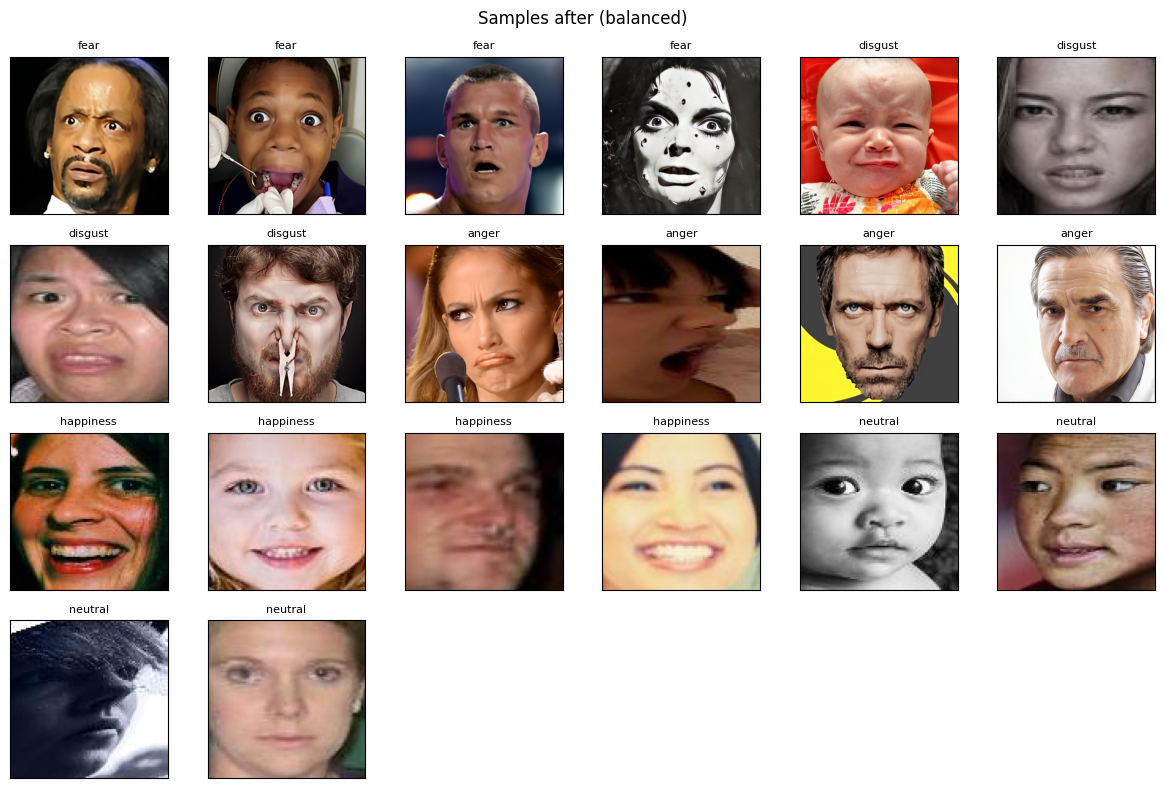

Before: {'surprise': 5915, 'fear': 3977, 'disgust': 3537, 'happiness': 11002, 'sadness': 5890, 'anger': 4505, 'neutral': 8336}
After : {'surprise': 2000, 'fear': 1984, 'disgust': 1990, 'happiness': 2000, 'sadness': 2000, 'anger': 1995, 'neutral': 2000}
surprise  : +-3915 (from 5915 to 2000)
fear      : +-1993 (from 3977 to 1984)
disgust   : +-1547 (from 3537 to 1990)
happiness : +-9002 (from 11002 to 2000)
sadness   : +-3890 (from 5890 to 2000)
anger     : +-2510 (from 4505 to 1995)
neutral   : +-6336 (from 8336 to 2000)


In [1]:

# =======================
# 0) Config
# =======================

DATA_ROOT = "/content/data"
TARGET_CLASSES = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
TARGET_PER_CLASS = 2000  # or min(existing_counts.values())
CALIBRATION_CLASSES = []
CALIBRATION_RATIO = 0


# kagglehub dataset IDs
RAF_SLUG = "shuvoalok/raf-db-dataset"
AFFECT_SLUG = "manavukani/affectnet"

# ========================================
# 1) Download datasets with kagglehub
# ========================================

# install kagglehub just for download convenience
try:
    import kagglehub  # noqa
except Exception:
    %pip -q install kagglehub

import os, glob, shutil, pathlib
from pathlib import Path
import kagglehub

def kh_download(slug, dest_root):
    if not slug:
        print("Slug empty, skipping.")
        return None
    print(f"Downloading via kagglehub: {slug}")
    p = kagglehub.dataset_download(slug)
    print("kagglehub path:", p)
    # Copy or link into DATA_ROOT
    dest = Path(dest_root)
    dest.mkdir(parents=True, exist_ok=True)
    # If path contains zips, expand them into dest
    # First, mirror folder into dest to simplify later paths
    if Path(p).resolve() != dest.resolve():
        # try to move contents, keep idempotent
        for item in Path(p).iterdir():
            tgt = dest / item.name
            if item.is_dir():
                if not tgt.exists():
                    shutil.copytree(item, tgt)
            else:
                if not tgt.exists():
                    shutil.copy2(item, tgt)
    # Unzip any archives found
    zips = list(dest.rglob("*.zip"))
    for z in zips:
        os.system(f'unzip -q -o "{z}" -d "{z.parent}"')
    return str(dest)

raf_root = kh_download(RAF_SLUG, os.path.join(DATA_ROOT, "raf-db"))
aff_root = kh_download(AFFECT_SLUG, os.path.join(DATA_ROOT, "affectnet"))
print("RAF root:", raf_root)
print("AffectNet root:", aff_root)

# ========================================
# 2) Imports and helpers
# ========================================

import os, sys, glob, random, json, math, time, hashlib
from collections import Counter, defaultdict
import pandas as pd
import torch
import torchvision
from torchvision.io import read_image
import matplotlib.pyplot as plt

random.seed(17)
torch.manual_seed(17)
os.makedirs(DATA_ROOT, exist_ok=True)

STD_LABELS = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
IMG_EXTS = {'.jpg','.jpeg','.png'}

# ========================================
# 3) Label normalization + folder-label inference
# ========================================

# Mapping for RAF-DB numeric scheme
LABEL_MAP_NUMERIC_RAF = {
    1: 'surprise',
    2: 'fear',
    3: 'disgust',
    4: 'happiness',
    5: 'sadness',
    6: 'anger',
    7: 'neutral'
}

# Mapping for AffectNet folder names to match RAF numeric
AFFECTNET_TO_NUMERIC = {
    'surprise': 1,
    'fear': 2,
    'disgust': 3,
    'happy': 4,       # affectnet folder uses "happy"
    'happiness': 4,
    'sad': 5,
    'sadness': 5,
    'anger': 6,
    'neutral': 7,
    # contempt dropped
}


def normalize_label(name_or_idx, dataset='raf'):
    """
    Converts folder or numeric labels to RAF-DB 7-label scheme.
    For AffectNet, maps emotion names to equivalent numeric IDs (1–7).
    """
    if isinstance(name_or_idx, str):
        s = name_or_idx.strip().lower()
        if s == 'contempt':
            return None  # drop contempt
        # convert AffectNet folder names to numeric RAF mapping if needed
        if dataset == 'affectnet':
            num = AFFECTNET_TO_NUMERIC.get(s)
            if num is None:
                return None
            return LABEL_MAP_NUMERIC_RAF[num]
        else:
            # for RAF-DB text labels (already normalized)
            s = s.replace('happy', 'happiness')
            if s == 'sad': s = 'sadness'
            if s == 'surprised': s = 'surprise'
            if s == 'neutrality': s = 'neutral'
            return s if s in LABEL_MAP_NUMERIC_RAF.values() else None

    else:
        # numeric inputs (e.g., from RAF annotation file)
        lab = LABEL_MAP_NUMERIC_RAF.get(int(name_or_idx))
        return lab


def label_from_path(path):
    """
    Infers emotion label from file path.
    Handles both RAF numeric folders and AffectNet emotion folders.
    """
    parts = [p.lower() for p in os.path.normpath(path).split(os.sep)]
    for p in reversed(parts):
        # AffectNet-style folder names
        if p in AFFECTNET_TO_NUMERIC:
            return LABEL_MAP_NUMERIC_RAF[AFFECTNET_TO_NUMERIC[p]]
        # RAF-DB numeric folders
        if p.isdigit():
            lab = LABEL_MAP_NUMERIC_RAF.get(int(p))
            if lab:
                return lab
    return None


def iter_images(root):
    for p in glob.glob(os.path.join(root, "**", "*"), recursive=True):
        if os.path.isfile(p) and os.path.splitext(p)[1].lower() in IMG_EXTS:
            yield p

# ========================================
# 4) Parsers with CSV/official first, folder fallback
# ========================================

def scan_raf_db(root):
    records = []
    if not root or not os.path.isdir(root):
        return records

    ann_files = glob.glob(os.path.join(root, "**", "list_patition_label.txt"), recursive=True)
    if ann_files:
        ann = sorted(ann_files)[0]
        img_index = {os.path.basename(f).lower(): f for f in iter_images(root)}
        with open(ann, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 2: continue
                fname, lab = parts
                try:
                    lab_i = int(lab)
                except:
                    continue
                lab_name = normalize_label(lab_i, dataset='raf')
                if lab_name is None: continue
                key = os.path.basename(fname).lower()
                if key in img_index:
                    records.append({"path": img_index[key], "label": lab_name})
        if records:
            return records

    # Folder-label fallback
    for p in iter_images(root):
        lab = label_from_path(p)
        if lab:
            records.append({"path": p, "label": lab})
    return records


def scan_affectnet(root):
    records = []
    if not root or not os.path.isdir(root):
        return records

    csvs = []
    for name in ["training.csv","validation.csv","validation_manual.csv","training_manual.csv","annotations.csv"]:
        csvs += glob.glob(os.path.join(root, "**", name), recursive=True)
    csvs = sorted(set(csvs))

    if csvs:
        img_roots = [p for p in glob.glob(os.path.join(root, "**"), recursive=True) if os.path.isdir(p)]
        def resolve_path(subpath):
            if os.path.isabs(subpath) and os.path.exists(subpath): return subpath
            sp = str(subpath).replace("\\","/")
            for ir in img_roots:
                cand = os.path.join(ir, sp)
                if os.path.exists(cand): return cand
                base = os.path.basename(sp)
                g = glob.glob(os.path.join(ir, "**", base), recursive=True)
                if g: return g[0]
            return None

        for csvp in csvs:
            try:
                df = pd.read_csv(csvp)
            except Exception:
                continue
            ecol = None
            for c in df.columns:
                if c.lower() == 'expression':
                    ecol = c; break
            fcols = [c for c in df.columns if 'file' in c.lower() or 'path' in c.lower()]
            if ecol is None or not fcols:
                continue
            fcol = fcols[0]
            for _, row in df.iterrows():
                try:
                    expr = int(row[ecol])
                except:
                    continue
                lab = normalize_label(expr, dataset='affectnet')
                if lab is None: continue
                p = resolve_path(row[fcol])
                if p and os.path.splitext(p)[1].lower() in IMG_EXTS:
                    records.append({"path": p, "label": lab})
        if records:
            return records

    # Folder-label fallback
    for p in iter_images(root):
        lab = label_from_path(p)
        if lab:
            records.append({"path": p, "label": lab})
    return records

# ======================
# 5) Diagnostics
# ======================

raf_root = os.path.join(DATA_ROOT, "raf-db")
aff_root = os.path.join(DATA_ROOT, "affectnet")

def diag(root, name):
    imgs = list(iter_images(root)) if root and os.path.isdir(root) else []
    lbls = sum(1 for p in imgs[:10000] if label_from_path(p))
    print(f"[{name}] root={root}")
    print("  total images:", len(imgs))
    print("  label-from-path matches (sampled):", lbls)

diag(raf_root, "RAF-DB")
diag(aff_root, "AffectNet")

# ========================================
# 6) Counts before
# ========================================

raf_records = scan_raf_db(raf_root)
aff_records = scan_affectnet(aff_root)

print(f"RAF-DB images parsed: {len(raf_records)}")
print(f"AffectNet images parsed: {len(aff_records)}")

def counts_by_label(records):
    c = Counter([r["label"] for r in records if r.get("label") in STD_LABELS])
    return {k:int(c.get(k,0)) for k in STD_LABELS}

raf_counts = counts_by_label(raf_records)
aff_counts = counts_by_label(aff_records)
merged_before = raf_records + aff_records
merged_before_counts = counts_by_label(merged_before)

print("RAF-DB counts:", raf_counts)
print("AffectNet counts:", aff_counts)
print("Merged counts:", merged_before_counts)

# ========================================
# 7) Visuals before
# ========================================

def plot_bar_counts(d, title):
    labels = list(['surprise','fear','disgust','happiness','sadness','anger','neutral'])
    vals = [d.get(l,0) for l in labels]
    plt.figure(figsize=(8,4))
    plt.bar(labels, vals)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.ylabel("count")
    plt.show()

plot_bar_counts(raf_counts, "RAF-DB class distribution (before)")
plot_bar_counts(aff_counts, "AffectNet class distribution (before)")
plot_bar_counts(merged_before_counts, "Merged class distribution (before)")

# ========================================
# 8) Targeted + calibration balancing
# ========================================

def to_std(name):
    n = name.strip().lower()
    if n.startswith("happy"): return "happiness"
    if n == "neutral": return "neutral"
    return n if n in ['surprise','fear','disgust','happiness','sadness','anger','neutral'] else None

TARGET_CLASSES_STD = [to_std(x) for x in TARGET_CLASSES if to_std(x) is not None]
CALIBRATION_CLASSES_STD = [to_std(x) for x in CALIBRATION_CLASSES if to_std(x) is not None]

print("Target classes:", TARGET_CLASSES_STD)
print("Calibration classes:", CALIBRATION_CLASSES_STD)

from collections import defaultdict
aff_by_label = defaultdict(list)
for r in aff_records:
    aff_by_label[r["label"]].append(r)

balanced = list(raf_records)

deficit = {cls: max(0, TARGET_PER_CLASS - sum(1 for r in balanced if r['label']==cls))
           for cls in TARGET_CLASSES_STD}
total_deficit = sum(deficit.values())

import random
def sample_wo(pool, k):
    if k <= 0: return []
    if len(pool) <= k: return list(pool)
    return random.sample(pool, k)

added_from_aff = []
for cls, need in deficit.items():
    pool = aff_by_label.get(cls, [])
    take = min(need, len(pool))
    added_from_aff.extend(sample_wo(pool, take))

calibration_total = int(CALIBRATION_RATIO * total_deficit)
if CALIBRATION_CLASSES_STD and calibration_total > 0:
    per_cls = max(1, calibration_total // len(CALIBRATION_CLASSES_STD))
    for cls in CALIBRATION_CLASSES_STD:
        pool = aff_by_label.get(cls, [])
        added_from_aff.extend(sample_wo(pool, min(per_cls, len(pool))))

print("Added from AffectNet:", len(added_from_aff))
balanced.extend(added_from_aff)

# ========================================
# 9) Deduplicate and shuffle
# ========================================

import hashlib, random

def sha1_of_file(p, chunk=1<<20):
    h = hashlib.sha1()
    try:
        with open(p, "rb") as f:
            while True:
                b = f.read(chunk)
                if not b: break
                h.update(b)
        return h.hexdigest()
    except Exception:
        return None

def dedup_by_hash(records):
    seen = set(); out = []
    for r in records:
        hv = sha1_of_file(r["path"])
        if not hv: continue
        if hv in seen: continue
        seen.add(hv)
        out.append(r)
    return out

balanced_dedup = dedup_by_hash(balanced)
random.shuffle(balanced_dedup)
print("After dedup total:", len(balanced_dedup))

# ========================================
# 10) Downsample overrepresented classes to target; reduce overrepresented classes to balance dataset.
# ========================================

balanced_final = []
for cls in STD_LABELS:
    cls_items = [r for r in balanced_dedup if r["label"] == cls]
    if len(cls_items) > TARGET_PER_CLASS:
        cls_items = random.sample(cls_items, TARGET_PER_CLASS)
    balanced_final.extend(cls_items)

balanced_dedup = balanced_final
print("After full rebalance (downsample+topup):", {c: sum(r["label"]==c for r in balanced_dedup) for c in STD_LABELS})

# ========================================
# 11) After counts + grids
# ========================================

after_counts = Counter([r["label"] for r in balanced_dedup])
after_counts = {k:int(after_counts.get(k,0)) for k in ['surprise','fear','disgust','happiness','sadness','anger','neutral']}
print("Counts after:", after_counts)

def plot_bar_counts(d, title):
    labels = list(['surprise','fear','disgust','happiness','sadness','anger','neutral'])
    vals = [d.get(l,0) for l in labels]
    plt.figure(figsize=(8,4))
    plt.bar(labels, vals)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.ylabel("count")
    plt.show()

plot_bar_counts(after_counts, "Class distribution (after balancing)")

def show_grid(records, title, per_class=4, classes=None):
    if classes is None:
        classes = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
    samples = []
    for cls in classes:
        cls_items = [r for r in records if r["label"] == cls]
        pick = random.sample(cls_items, min(per_class, len(cls_items))) if cls_items else []
        for r in pick:
            samples.append((cls, r["path"]))
    if not samples:
        print(f"No samples for: {title}")
        return
    cols = 6
    rows = math.ceil(len(samples)/cols)
    plt.figure(figsize=(cols*2, rows*2))
    idx = 1
    for cls, p in samples:
        try:
            img = read_image(p).clamp(0,255).to(torch.uint8)
            arr = img.permute(1,2,0).numpy()
            plt.subplot(rows, cols, idx)
            plt.imshow(arr); plt.xticks([]); plt.yticks([])
            plt.title(cls, fontsize=8)
            idx += 1
        except Exception:
            pass
    plt.suptitle(title); plt.tight_layout(); plt.show()

REP = ['fear','disgust','anger','happiness','neutral']
show_grid(raf_records + aff_records, "Samples before (merged)", per_class=4, classes=REP)
show_grid(balanced_dedup, "Samples after (balanced)", per_class=4, classes=REP)

# ========================================
# 12) Summary
# ========================================

def counts_by_label(records):
    c = Counter([r["label"] for r in records if r.get("label") in ['surprise','fear','disgust','happiness','sadness','anger','neutral']])
    return {k:int(c.get(k,0)) for k in ['surprise','fear','disgust','happiness','sadness','anger','neutral']}

before = counts_by_label(raf_records + aff_records)
after = counts_by_label(balanced_dedup)
print("Before:", before)
print("After :", after)
for cls in ['surprise','fear','disgust','happiness','sadness','anger','neutral']:
    b = before.get(cls,0); a = after.get(cls,0)
    print(f"{cls:10s}: +{a-b} (from {b} to {a})")



# 2. Training-ready data prep:

Using the final balanced list `balanced_dedup`. A Dataset is built from file paths and labels.

Applied ImageNet normalization and light augmentation, do a stratified split, and compute optional class weights.

Benefit: Clean, reproducible inputs aligned to ResNet18 with stable label indices and balanced evaluation.

In [2]:
# --- Imports
import os, random, math
from collections import Counter
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets.folder import default_loader  # PIL loader
from torchvision import transforms

from sklearn.model_selection import train_test_split

# --- Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Constants
# Keep the exact canonical order to match previous work

STD_LABELS = ['surprise','fear','disgust','happiness','sadness','anger','neutral']
label_to_idx = {name: i for i, name in enumerate(STD_LABELS)}
idx_to_label = {i: name for name, i in label_to_idx.items()}

VAL_SIZE = 0.15
BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
USE_CLASS_WEIGHTS = True  # set False to disable

# --- Transforms
# Benefit: Faster convergence and improved generalization.

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- Dataset from records
# Expects a list of dicts like: {"path": ".../img.jpg", "label": "happiness"}

class PathLabelDataset(Dataset):
    def __init__(self, records, transform=None, strict=True):
        self.transform = transform
        self.loader = default_loader
        # Filter records to known labels and existing files
        filtered = []
        for r in records:
            lab = r.get("label", "").strip().lower()
            pth = r.get("path", "")
            if lab in label_to_idx and isinstance(pth, str) and os.path.isfile(pth):
                filtered.append((pth, label_to_idx[lab]))
        if strict and not filtered:
            raise RuntimeError("No valid samples found. Check paths and labels.")
        self.samples = filtered

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, target = self.samples[i]
        img = self.loader(path)  # PIL
        if self.transform is not None:
            img = self.transform(img)
        return img, target

# --- Pull labels from the final list for stratification
_all_paths = []
_all_targets = []
for r in balanced_dedup:
    lab = r.get("label", "").strip().lower()
    pth = r.get("path", "")
    if lab in label_to_idx and isinstance(pth, str) and os.path.isfile(pth):
        _all_paths.append(pth)
        _all_targets.append(label_to_idx[lab])

if len(_all_paths) == 0:
    raise RuntimeError("No valid files in balanced_dedup. Verify paths exist on this runtime.")

indices = np.arange(len(_all_paths))
y = np.array(_all_targets)
train_idx, val_idx = train_test_split(
    indices, test_size=VAL_SIZE, random_state=SEED, stratify=y
)

# Rebuild record lists for each split to feed PathLabelDataset
train_records = [{"path": _all_paths[i], "label": STD_LABELS[_all_targets[i]]} for i in train_idx]
val_records   = [{"path": _all_paths[i], "label": STD_LABELS[_all_targets[i]]} for i in val_idx]

train_ds = PathLabelDataset(train_records, transform=train_tf)
val_ds   = PathLabelDataset(val_records,   transform=eval_tf)

# --- Optional class weights from training split
# Why: Guard against minor residual imbalance even after balancing.
# Benefit: More stable gradients across classes.

class_weights = None
if USE_CLASS_WEIGHTS:
    train_counts = Counter([t for _, t in [ (None, label_to_idx[r["label"]]) for r in train_records ]])
    inv = np.array([1.0 / max(1, train_counts.get(c, 0)) for c in range(len(STD_LABELS))], dtype=np.float32)
    inv = inv * (len(inv) / inv.sum())  # normalize to sum=num_classes
    class_weights = torch.tensor(inv, dtype=torch.float32)

# --- DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# --- Sanity checks
def count_by_idx(dataset):
    c = Counter()
    for _, t in dataset:
        c[int(t)] += 1
    return {idx_to_label[k]: int(v) for k, v in sorted(c.items())}

print("Classes (idx->name):", idx_to_label)
print("Train size:", len(train_ds), " Val size:", len(val_ds))
print("Train class counts:", count_by_idx(train_ds))
print("Val class counts:",   count_by_idx(val_ds))
if class_weights is not None:
    print("Class weights:", class_weights.tolist())

# --- Example criterion for later:
# import torch.nn as nn
# criterion = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()
#
# --- Example model setup for later:
# from torchvision.models import resnet18
# model = resnet18(weights='IMAGENET1K_V1')
# model.fc = torch.nn.Linear(model.fc.in_features, len(STD_LABELS))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classes (idx->name): {0: 'surprise', 1: 'fear', 2: 'disgust', 3: 'happiness', 4: 'sadness', 5: 'anger', 6: 'neutral'}
Train size: 11873  Val size: 2096
Train class counts: {'surprise': 1700, 'fear': 1686, 'disgust': 1691, 'happiness': 1700, 'sadness': 1700, 'anger': 1696, 'neutral': 1700}
Val class counts: {'surprise': 300, 'fear': 298, 'disgust': 299, 'happiness': 300, 'sadness': 300, 'anger': 299, 'neutral': 300}
Class weights: [0.997721791267395, 1.0060065984725952, 1.0030319690704346, 0.997721791267395, 0.997721791267395, 1.0000749826431274, 0.997721791267395]


In [3]:
# ========================================
# 13) Hybrid Mini-Xception + MobileNetV2 Model, Training, Evaluation, and Saving
# ========================================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_score, classification_report, confusion_matrix
from google.colab import drive
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torchvision import models

In [4]:

# --- 13.1) Mount Google Drive
drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/emotion_models"
os.makedirs(DRIVE_PATH, exist_ok=True)

Mounted at /content/drive


In [5]:

# --- 13.2) Define Mini-Xception block
class MiniXceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.conv(x)


In [6]:
# --- 13.3) Define Hybrid Model
class HybridMiniXMobile(nn.Module):
    def __init__(self, num_classes=len(STD_LABELS)):
        super().__init__()
        # MobileNetV2 backbone
        mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1')
        self.mobilenet_features = mobilenet.features
        self.mobilenet_pool = nn.AdaptiveAvgPool2d(1)

        # Mini-Xception path
        self.mini_block1 = MiniXceptionBlock(3, 32)
        self.mini_block2 = MiniXceptionBlock(32, 64)
        self.mini_block3 = MiniXceptionBlock(64, 128)
        self.mini_pool = nn.AdaptiveAvgPool2d(1)

        # Fusion classifier
        self.fc = nn.Linear(128 + 1280, num_classes)

    def forward(self, x):
        # MobileNet features
        m_feat = self.mobilenet_features(x)
        m_feat = self.mobilenet_pool(m_feat)
        m_feat = m_feat.view(m_feat.size(0), -1)

        # Mini-Xception features
        mx = self.mini_block1(x)
        mx = self.mini_block2(mx)
        mx = self.mini_block3(mx)
        mx = self.mini_pool(mx)
        mx = mx.view(mx.size(0), -1)

        # Concatenate
        fused = torch.cat([m_feat, mx], dim=1)
        out = self.fc(fused)
        return out


In [7]:
# --- 13.4) Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridMiniXMobile(num_classes=len(STD_LABELS)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
NUM_EPOCHS = 25


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 171MB/s]


In [8]:
# --- 13.5) Training Loop

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_precision": []}

for epoch in range(NUM_EPOCHS):
    # --- Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / total
    val_acc = correct / total
    val_prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_prec)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Precision: {val_prec:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/25 | Train Loss: 1.1642, Acc: 0.5600 | Val Loss: 0.9952, Acc: 0.6135, Precision: 0.6266


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 2/25 | Train Loss: 0.9108, Acc: 0.6596 | Val Loss: 0.8731, Acc: 0.6741, Precision: 0.6753


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

Epoch 23/25 | Train Loss: 0.3782, Acc: 0.8602 | Val Loss: 0.9126, Acc: 0.7328, Precision: 0.7409


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 24/25 | Train Loss: 0.3466, Acc: 0.8727 | Val Loss: 0.9272, Acc: 0.7142, Precision: 0.7227


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 25/25 | Train Loss: 0.3529, Acc: 0.8703 | Val Loss: 0.8388, Acc: 0.7357, Precision: 0.7383


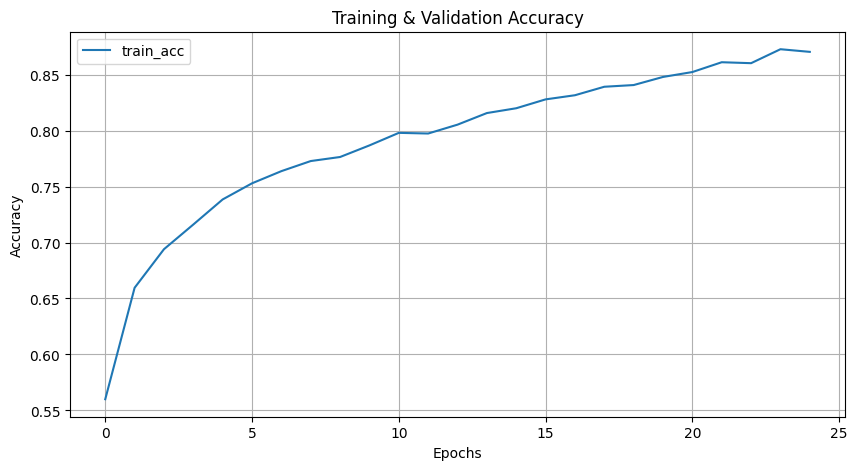

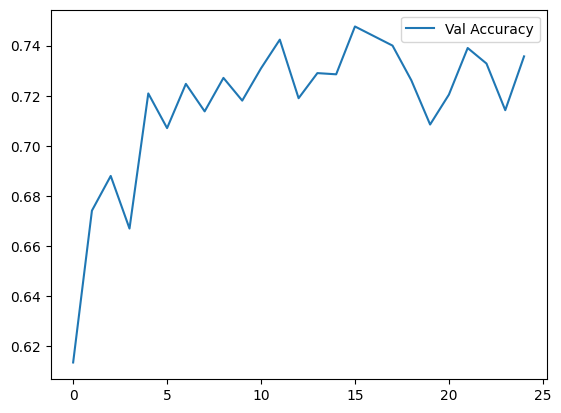

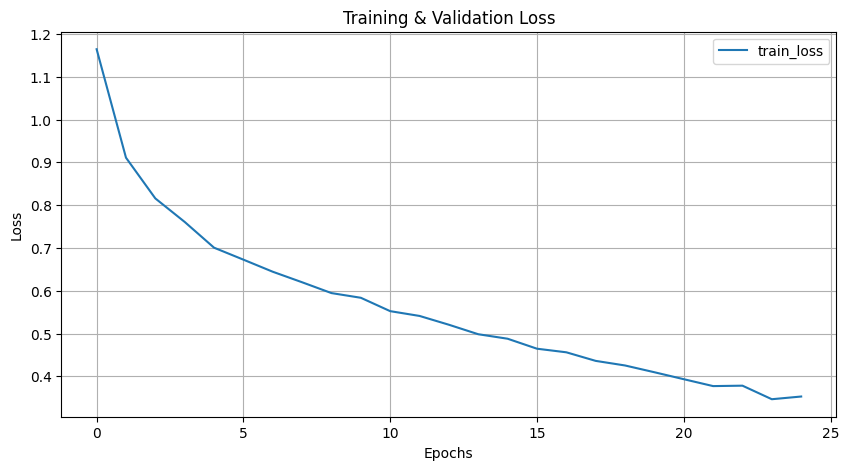

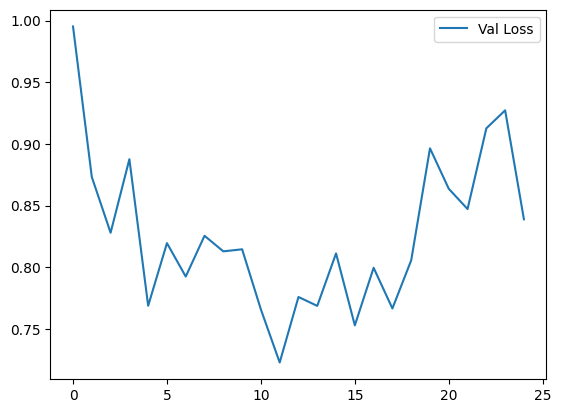

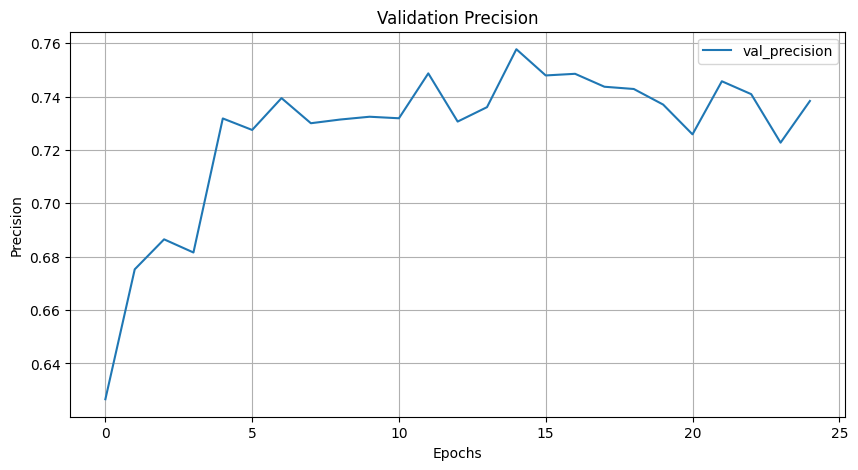

In [9]:
# --- 13.7) Plots
def plot_metric(history, key, title, ylabel, save_name):
    plt.figure(figsize=(10,5))
    plt.plot(history[key], label=key)
    plt.xlabel("Epochs"); plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(DRIVE_PATH, save_name))
    plt.show()

plot_metric(history, "train_acc", "Training & Validation Accuracy", "Accuracy", "accuracy_plot.png")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.legend(); plt.show()

plot_metric(history, "train_loss", "Training & Validation Loss", "Loss", "loss_plot.png")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend(); plt.show()

plot_metric(history, "val_precision", "Validation Precision", "Precision", "precision_plot.png")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

    surprise       0.73      0.72      0.73       300
        fear       0.71      0.67      0.69       298
     disgust       0.62      0.67      0.64       299
   happiness       0.89      0.86      0.88       300
     sadness       0.75      0.81      0.78       300
       anger       0.78      0.68      0.72       299
     neutral       0.69      0.74      0.71       300

    accuracy                           0.74      2096
   macro avg       0.74      0.74      0.74      2096
weighted avg       0.74      0.74      0.74      2096

Saved classification report to: /content/drive/MyDrive/emotion_models/classification_report.txt


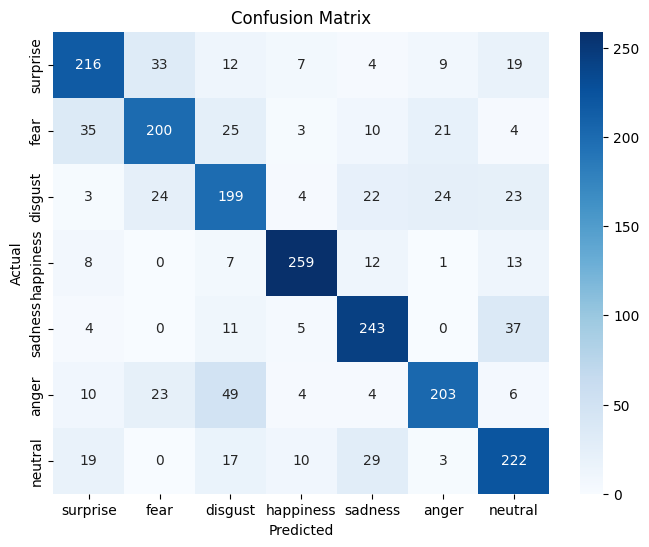

In [10]:
# --- 13.8) Classification report + confusion matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

report = classification_report(all_labels, all_preds, target_names=STD_LABELS, zero_division=0)
print("Classification Report:\n", report)
report_path = os.path.join(DRIVE_PATH, "classification_report.txt")
with open(report_path, "w") as f:
    f.write(report)
print("Saved classification report to:", report_path)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=STD_LABELS, yticklabels=STD_LABELS, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(DRIVE_PATH, "confusion_matrix.png"))
plt.show()

In [11]:
s

⚠️ No best_hybrid.pt found, exporting in-memory model weights...
✅ Wrote raf_affectnet_balanced_HybridMiniXMobile.pt and labels.txt
✅ Sanity check passed, output shape: torch.Size([1, 7])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>